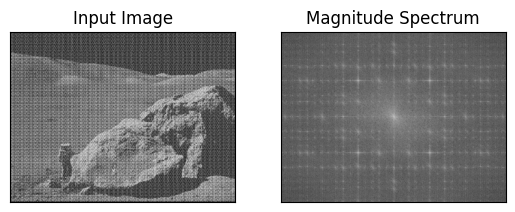

In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max
img = cv.imread('periodic_noise.jpg', cv.IMREAD_GRAYSCALE)
 
dft = cv.dft(np.float32(img),flags = cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
 
magnitude_spectrum = 20*np.log(cv.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))
 
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

In [2]:
#Filter creating
# Low pass filter
mask = np.zeros((img.shape[0],img.shape[1],2),np.uint8)
centerX, centerY = (int(img.shape[0] / 2),int(img.shape[1] / 2))
mask[centerX-50:centerX+50, centerY - 50:centerY+50,:] = 1

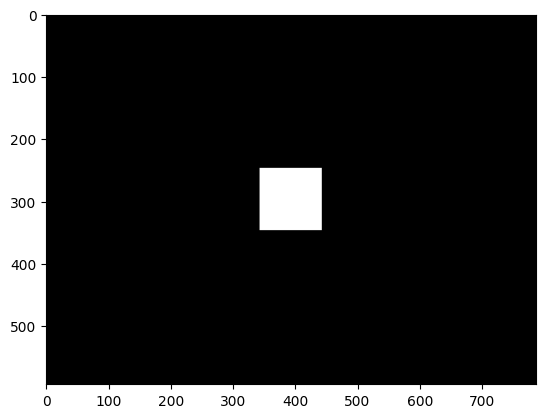

In [3]:
plt.imshow(mask[:,:,0], cmap = 'gray')


In [4]:
# Filtering
dft_shift = dft_shift*mask


C:\Users\timur\AppData\Local\Temp\ipykernel_812\3830399572.py:1: RuntimeWarning: divide by zero encountered in log
  filtering_magn_res = 20*np.log(cv.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))


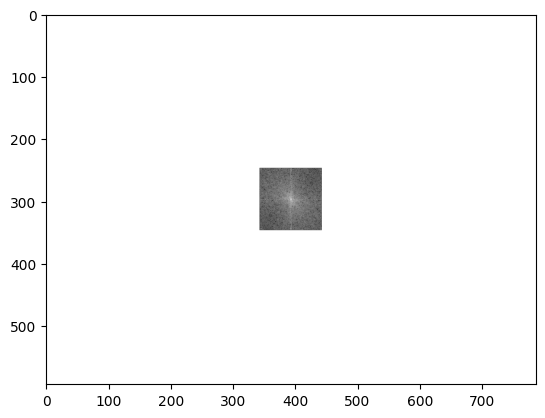

In [5]:
filtering_magn_res = 20*np.log(cv.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))
plt.imshow(filtering_magn_res, cmap='gray')

In [6]:
#fshift = dft_shift*mask
f_ishift = np.fft.ifftshift(dft_shift)
img_back = cv.idft(f_ishift)
img_back = cv.magnitude(img_back[:,:,0],img_back[:,:,1])

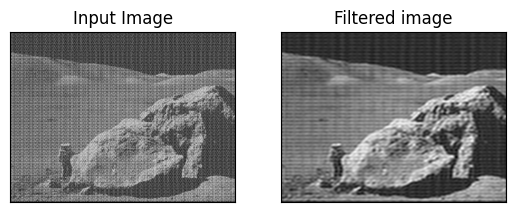

In [7]:
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_back, cmap = 'gray')
plt.title('Filtered image'), plt.xticks([]), plt.yticks([])
plt.show()

In [8]:
# Реализуйте высокочастотную фильтрацию на основе ядра Гаусса
# Реализуйте удаление периодического шума


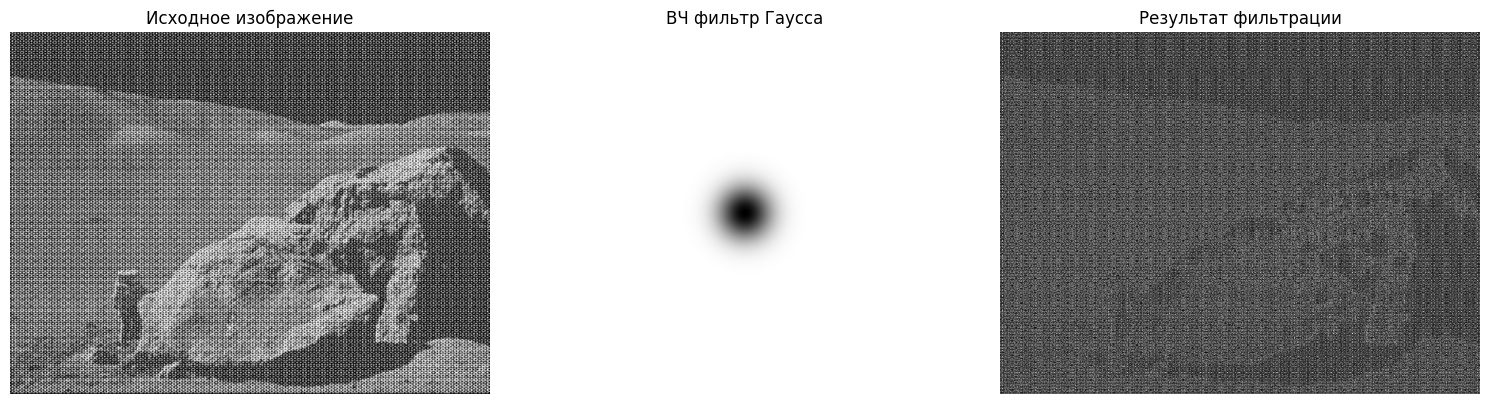

In [10]:
# Реализуйте высокочастотную фильтрацию на основе ядра Гаусса
image = cv.imread('periodic_noise.jpg')
image_gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY) 

def gaussian_highpass_filter(img, sigma=30):
    # Прямое преобразование Фурье
    dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    
    rows, cols = img.shape
    center_row, center_col = rows // 2, cols // 2
    
    # Создание координатной сетки
    y, x = np.ogrid[:rows, :cols]
    
    # Вычисление расстояний от центра
    dist_from_center = np.sqrt((x - center_col)**2 + (y - center_row)**2)
    
    # Создание гауссова ВЧ фильтра
    gaussian_lowpass = np.exp(-(dist_from_center**2) / (2 * sigma**2))
    gaussian_highpass = 1.0 - gaussian_lowpass
    
    # Применение фильтра к реальной и мнимой частям
    filtered_dft = dft_shift * gaussian_highpass[:, :, np.newaxis]
    
    # Обратное преобразование Фурье
    idft_shift = np.fft.ifftshift(filtered_dft)
    reconstructed = cv.idft(idft_shift)
    magnitude = cv.magnitude(reconstructed[:,:,0], reconstructed[:,:,1])
    
    # Нормализация результата
    normalized_result = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX)
    final_image = normalized_result.astype(np.uint8)
    
    return final_image, gaussian_highpass

# Применение фильтра
highpass_result, gaussian_mask = gaussian_highpass_filter(image_gray)

# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title('Исходное изображение')
axes[0].axis('off')

axes[1].imshow(gaussian_mask, cmap='gray')
axes[1].set_title('ВЧ фильтр Гаусса')
axes[1].axis('off')

axes[2].imshow(highpass_result, cmap='gray')
axes[2].set_title('Результат фильтрации')
axes[2].axis('off')

plt.tight_layout()
plt.show()

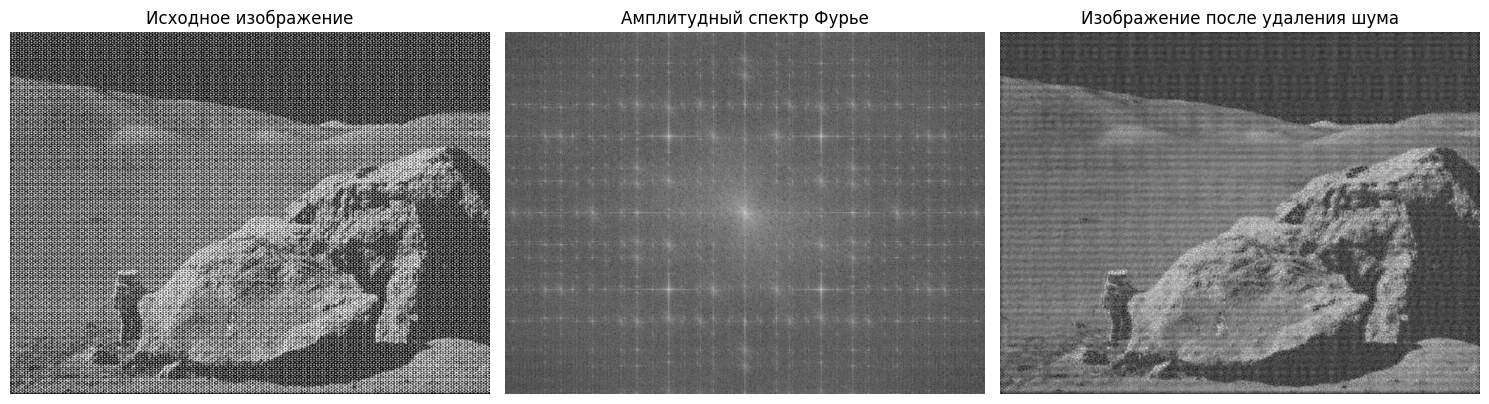

In [11]:
# Реализуйте удаление периодического шума
def remove_periodic_noise(img):
    # Прямое преобразование Фурье
    dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    
    # Вычисление амплитудного спектра в логарифмической шкале
    real_part = dft_shift[:,:,0]
    imag_part = dft_shift[:,:,1]
    magnitude_spectrum = 20 * np.log(cv.magnitude(real_part, imag_part) + 1e-10)
    
    # Создание маски шума на основе процентиля
    threshold_value = np.percentile(magnitude_spectrum, 96)
    noise_mask = magnitude_spectrum > threshold_value
    
    # Параметры центральной области
    rows, cols = img.shape
    center_row, center_col = rows // 2, cols // 2
    center_region_radius = min(rows, cols) // 10
    
    # Инициализация фильтрующей маски
    filter_mask = np.ones((rows, cols, 2), dtype=np.float32)
    
    # Применение маски к точкам шума вне центральной области
    for i in range(rows):
        for j in range(cols):
            if noise_mask[i, j]:
                distance_to_center = np.sqrt((j - center_col)**2 + (i - center_row)**2)
                if distance_to_center > center_region_radius:
                    filter_mask[i, j] = [0, 0]
                    # Симметричное подавление
                    symmetric_i = rows - 1 - i
                    symmetric_j = cols - 1 - j
                    filter_mask[symmetric_i, symmetric_j] = [0, 0]
    
    # Обратное преобразование Фурье
    filtered_spectrum = dft_shift * filter_mask
    restored_spectrum = np.fft.ifftshift(filtered_spectrum)
    reconstructed_image = cv.idft(restored_spectrum)
    image_magnitude = cv.magnitude(reconstructed_image[:,:,0], reconstructed_image[:,:,1])
    
    # Нормализация результата
    normalized_image = cv.normalize(image_magnitude, None, 0, 255, cv.NORM_MINMAX)
    final_result = normalized_image.astype(np.uint8)
    
    return final_result, magnitude_spectrum

# Применение функции удаления шума
denoised_image, magnitude_spectrum = remove_periodic_noise(image_gray)

# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title('Исходное изображение')
axes[0].axis('off')

axes[1].imshow(magnitude_spectrum, cmap='gray')
axes[1].set_title('Амплитудный спектр Фурье')
axes[1].axis('off')

axes[2].imshow(denoised_image, cmap='gray')
axes[2].set_title('Изображение после удаления шума')
axes[2].axis('off')

plt.tight_layout()
plt.show()